In [1]:
# ============================================================
# 1. Configuração do projeto — Composição temporal NDMI
# ============================================================

from pathlib import Path

projeto = Path(
    r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao"
)

pasta_ndmi = (
    projeto
    / "data"
    / "processed"
    / "indices"
    / "ndmi"
)

print("✓ Projeto:", projeto)
print("✓ Pasta dos NDMI:", pasta_ndmi)

✓ Projeto: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao
✓ Pasta dos NDMI: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\ndmi


In [2]:
# ============================================================
# 2. Localização e conferência dos rasters NDMI
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray

# Localiza os GeoTIFFs NDMI
arquivos = sorted(
    pasta_ndmi.glob("ndmi_2023*.tif")
)

print(f"✓ Arquivos NDMI encontrados: {len(arquivos)}")
print()

for arquivo in arquivos:
    print(f"  • {arquivo.name}")

# Verificação básica
if len(arquivos) == 0:
    raise FileNotFoundError(
        "❌ Nenhum arquivo NDMI foi encontrado."
    )

print()
print("✓ Arquivos localizados com sucesso.")

✓ Arquivos NDMI encontrados: 11

  • ndmi_20230208.tif
  • ndmi_20230325.tif
  • ndmi_20230404.tif
  • ndmi_20230524.tif
  • ndmi_20230628.tif
  • ndmi_20230713.tif
  • ndmi_20230817.tif
  • ndmi_20230911.tif
  • ndmi_20231011.tif
  • ndmi_20231105.tif
  • ndmi_20231220.tif

✓ Arquivos localizados com sucesso.


In [3]:
# ============================================================
# 3. Verificação espacial dos rasters NDMI
# ============================================================

print("=" * 70)
print("VERIFICAÇÃO DOS RASTERS NDMI")
print("=" * 70)

for arquivo in arquivos:

    raster = rioxarray.open_rasterio(
        arquivo,
        masked=True
    ).squeeze(drop=True)

    print()
    print(f"Arquivo: {arquivo.name}")
    print(f"  CRS: {raster.rio.crs}")
    print(f"  Resolução: {raster.rio.resolution()}")
    print(f"  Dimensões: {raster.rio.width} × {raster.rio.height}")
    print(f"  Bounds: {raster.rio.bounds()}")

print()
print("✓ Verificação concluída.")

VERIFICAÇÃO DOS RASTERS NDMI

Arquivo: ndmi_20230208.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112
  Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Arquivo: ndmi_20230325.tif
  CRS: EPSG:32723
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 111
  Bounds: (239820.0, 7400780.0, 241240.0, 7403000.0)

Arquivo: ndmi_20230404.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112
  Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Arquivo: ndmi_20230524.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112
  Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Arquivo: ndmi_20230628.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112
  Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Arquivo: ndmi_20230713.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112
  Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Arquivo: ndmi_20230817.tif
  CRS: EPSG:32723
  Resolução: (20.0, -20.0)
  Dimensõe

In [4]:
# ============================================================
# 4. Alinhamento espacial e criação do cubo temporal NDMI
# ============================================================

rasters = []

# ------------------------------------------------------------
# Raster de referência
# ------------------------------------------------------------

arquivo_referencia = arquivos[0]

referencia = rioxarray.open_rasterio(
    arquivo_referencia,
    masked=True
).squeeze(drop=True)

if referencia.rio.crs is None:
    raise ValueError(
        "❌ O raster de referência não possui CRS."
    )

print("Raster de referência:")
print(f"  Arquivo: {arquivo_referencia.name}")
print(f"  CRS: {referencia.rio.crs}")
print(f"  Resolução: {referencia.rio.resolution()}")
print(
    f"  Dimensões: "
    f"{referencia.rio.width} × {referencia.rio.height}"
)

print()
print("Alinhando rasters:")
print("-" * 70)


# ------------------------------------------------------------
# Leitura, alinhamento e criação da dimensão temporal
# ------------------------------------------------------------

for arquivo in arquivos:

    # Data no formato YYYYMMDD
    data_str = arquivo.stem[-8:]

    data = pd.to_datetime(
        data_str,
        format="%Y%m%d"
    )

    raster = rioxarray.open_rasterio(
        arquivo,
        masked=True
    ).squeeze(drop=True)

    if raster.rio.crs is None:
        raise ValueError(
            f"❌ O raster {arquivo.name} não possui CRS."
        )

    # Reprojeção/alinhamento para a grade de referência
    raster_alinhado = raster.rio.reproject_match(
        referencia
    )

    # Adiciona a dimensão temporal
    raster_alinhado = raster_alinhado.expand_dims(
        time=[data]
    )

    rasters.append(raster_alinhado)

    print(
        f"✓ {arquivo.name} → "
        f"{data.strftime('%d/%m/%Y')} → alinhado"
    )


# ------------------------------------------------------------
# Construção do cubo temporal
# ------------------------------------------------------------

cubo = xr.concat(
    rasters,
    dim="time",
    join="exact"
)

cubo = cubo.sortby("time")


print()
print("=" * 70)
print("CUBO TEMPORAL NDMI")
print("=" * 70)

print(f"✓ Número de imagens: {cubo.sizes['time']}")
print(f"✓ Linhas: {cubo.sizes['y']}")
print(f"✓ Colunas: {cubo.sizes['x']}")
print(f"✓ CRS: {cubo.rio.crs}")
print(f"✓ Resolução: {cubo.rio.resolution()}")
print(
    f"✓ Período: "
    f"{pd.to_datetime(cubo.time.values[0]).strftime('%d/%m/%Y')} "
    f"→ "
    f"{pd.to_datetime(cubo.time.values[-1]).strftime('%d/%m/%Y')}"
)

Raster de referência:
  Arquivo: ndmi_20230208.tif
  CRS: EPSG:32722
  Resolução: (20.0, -20.0)
  Dimensões: 71 × 112

Alinhando rasters:
----------------------------------------------------------------------
✓ ndmi_20230208.tif → 08/02/2023 → alinhado
✓ ndmi_20230325.tif → 25/03/2023 → alinhado
✓ ndmi_20230404.tif → 04/04/2023 → alinhado
✓ ndmi_20230524.tif → 24/05/2023 → alinhado
✓ ndmi_20230628.tif → 28/06/2023 → alinhado
✓ ndmi_20230713.tif → 13/07/2023 → alinhado
✓ ndmi_20230817.tif → 17/08/2023 → alinhado
✓ ndmi_20230911.tif → 11/09/2023 → alinhado
✓ ndmi_20231011.tif → 11/10/2023 → alinhado
✓ ndmi_20231105.tif → 05/11/2023 → alinhado
✓ ndmi_20231220.tif → 20/12/2023 → alinhado

CUBO TEMPORAL NDMI
✓ Número de imagens: 11
✓ Linhas: 112
✓ Colunas: 71
✓ CRS: EPSG:32722
✓ Resolução: (20.0, -20.0)
✓ Período: 08/02/2023 → 20/12/2023


In [5]:
# ============================================================
# 5. Composição temporal — Mediana NDMI
# ============================================================

ndmi_mediana = cubo.median(
    dim="time",
    skipna=True
)

print("✓ Composição mediana NDMI calculada")

print()
print("Dimensões:")
print(ndmi_mediana.dims)

print()
print("Shape:")
print(ndmi_mediana.shape)

✓ Composição mediana NDMI calculada

Dimensões:
('y', 'x')

Shape:
(112, 71)


In [6]:
# ============================================================
# 6. Estatísticas da composição mediana NDMI
# ============================================================

valores = ndmi_mediana.values

# Remove NoData / NaN
valores_validos = valores[
    np.isfinite(valores)
]

print("=" * 70)
print("ESTATÍSTICAS — COMPOSIÇÃO MEDIANA NDMI")
print("=" * 70)

print(
    f"✓ Pixels válidos: "
    f"{len(valores_validos):,}"
)

print(
    f"✓ Pixels NoData: "
    f"{np.count_nonzero(~np.isfinite(valores)):,}"
)

print(
    f"✓ Mínimo: "
    f"{np.min(valores_validos):.4f}"
)

print(
    f"✓ Máximo: "
    f"{np.max(valores_validos):.4f}"
)

print(
    f"✓ Média: "
    f"{np.mean(valores_validos):.4f}"
)

print(
    f"✓ Mediana: "
    f"{np.median(valores_validos):.4f}"
)

print(
    f"✓ Desvio-padrão: "
    f"{np.std(valores_validos):.4f}"
)

ESTATÍSTICAS — COMPOSIÇÃO MEDIANA NDMI
✓ Pixels válidos: 4,950
✓ Pixels NoData: 3,002
✓ Mínimo: -0.2404
✓ Máximo: 0.4334
✓ Média: 0.0608
✓ Mediana: 0.0546
✓ Desvio-padrão: 0.1732


In [7]:
# ============================================================
# 7. Exportação da composição mediana NDMI 
# ============================================================

saida = pasta_ndmi / "ndmi_mediana_2023.tif"

ndmi_mediana.rio.to_raster(
    saida,
    dtype="float32",
    compress="DEFLATE",
    predictor=3,
    tiled=True,
    BIGTIFF="IF_SAFER"
)

print("✓ Composição NDMI exportada")
print(f"✓ Arquivo: {saida}")

✓ Composição NDMI exportada
✓ Arquivo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices\ndmi\ndmi_mediana_2023.tif


In [8]:
# ============================================================
# 8. Validação do GeoTIFF exportado
# ============================================================

import rioxarray as rxr

ndmi_validado = rxr.open_rasterio(
    saida,
    masked=True
).squeeze()

print("=" * 60)
print("VALIDAÇÃO — NDMI MEDIANA")
print("=" * 60)

print(f"✓ Arquivo existe: {saida.exists()}")
print(f"✓ Dimensões: {ndmi_validado.shape}")
print(f"✓ CRS: {ndmi_validado.rio.crs}")
print(f"✓ Resolução: {ndmi_validado.rio.resolution()}")
print(f"✓ Bounds: {ndmi_validado.rio.bounds()}")

print("\nEstatísticas:")
print(f"✓ Pixels válidos: {ndmi_validado.count().item():,}")
print(f"✓ Mínimo: {float(ndmi_validado.min()):.4f}")
print(f"✓ Máximo: {float(ndmi_validado.max()):.4f}")
print(f"✓ Média: {float(ndmi_validado.mean()):.4f}")
print(f"✓ Mediana: {float(ndmi_validado.median()):.4f}")
print(f"✓ Desvio-padrão: {float(ndmi_validado.std()):.4f}")

print("=" * 60)

VALIDAÇÃO — NDMI MEDIANA
✓ Arquivo existe: True
✓ Dimensões: (112, 71)
✓ CRS: EPSG:32722
✓ Resolução: (20.0, -20.0)
✓ Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)

Estatísticas:
✓ Pixels válidos: 4,950
✓ Mínimo: -0.2404
✓ Máximo: 0.4334
✓ Média: 0.0608
✓ Mediana: 0.0546
✓ Desvio-padrão: 0.1732


Shape usado: (112, 71)
CRS: EPSG:32722
Bounds: (852780.0, 7398800.0, 854200.0, 7401040.0)
Resolução: (20.0, -20.0)

NDMI — min: -0.240 | max: 0.433
NDMI — média: 0.061 | mediana: 0.055
NDMI — p5: -0.202 | p95: 0.327


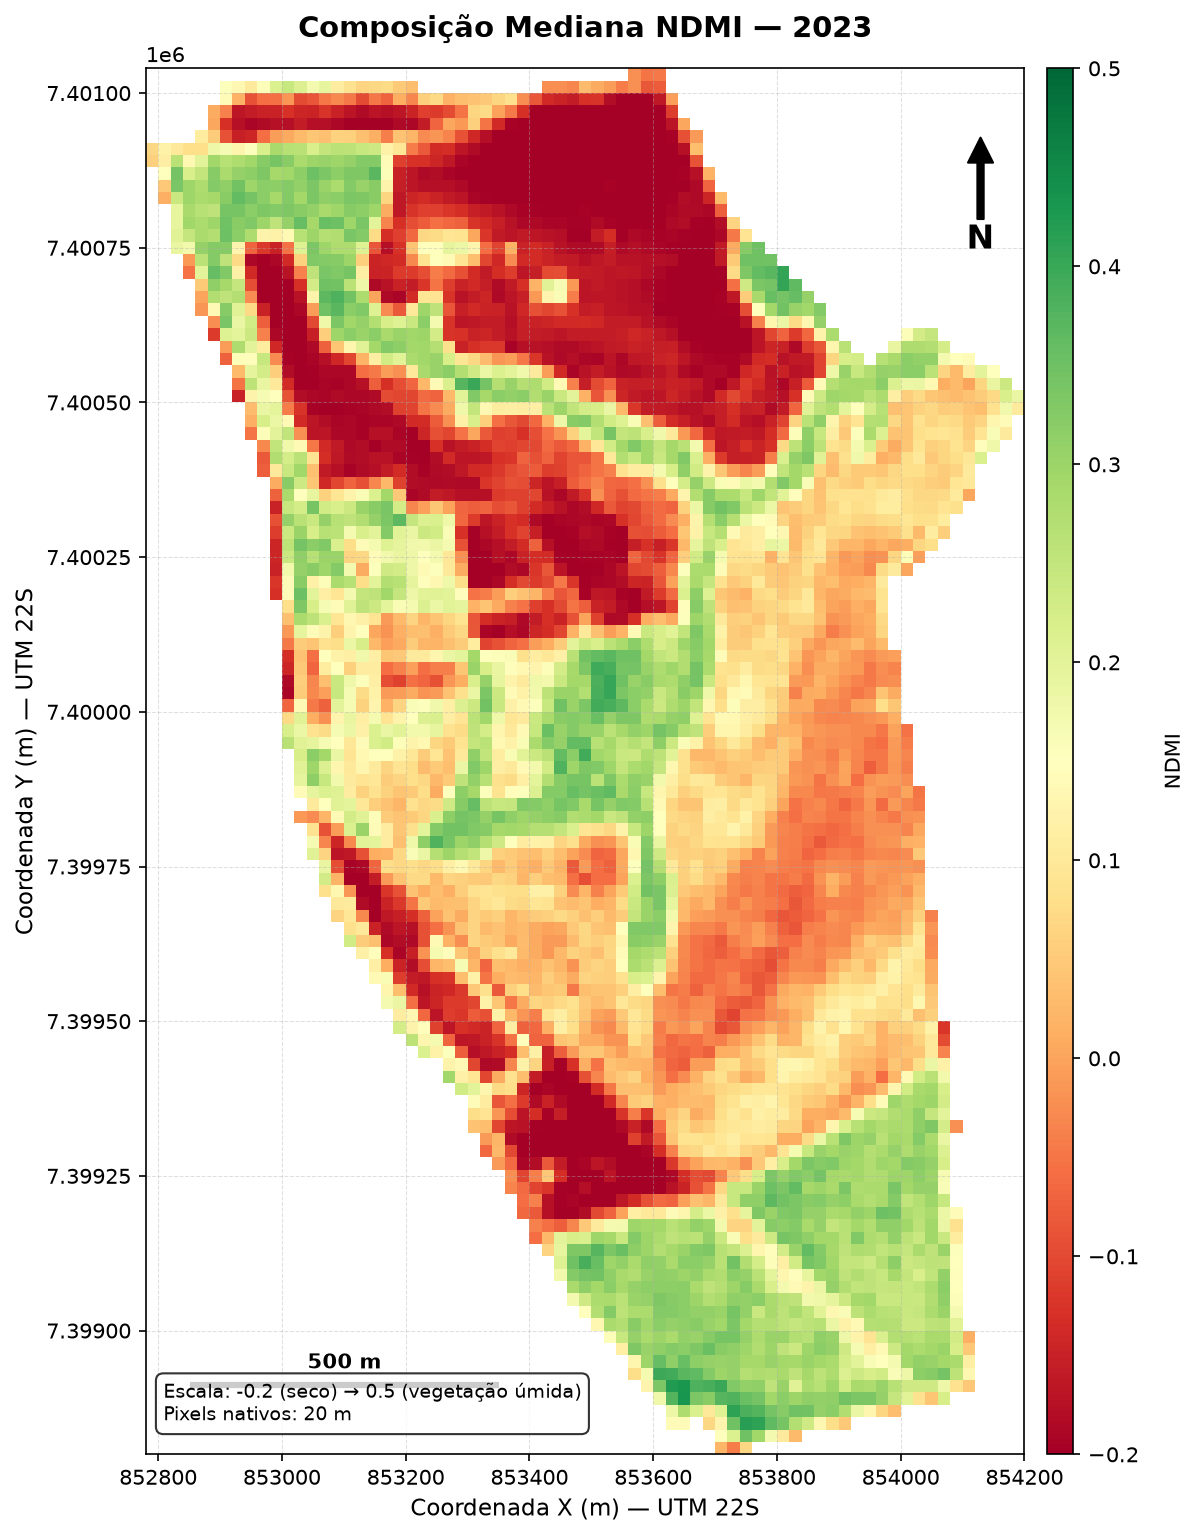

In [9]:
# ============================================================
# Visualização da composição mediana NDMI — 2023
# (usando a variável ndmi_mediana já carregada)
# ============================================================

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

# ------------------------------------------------------------
# Extrair array (lidar com 2D ou 3D)
# ------------------------------------------------------------
if len(ndmi_mediana.shape) == 3:
    ndmi_arr = ndmi_mediana.values[0]
else:
    ndmi_arr = ndmi_mediana.values

print(f"Shape usado: {ndmi_arr.shape}")
print(f"CRS: {ndmi_mediana.rio.crs}")
print(f"Bounds: {ndmi_mediana.rio.bounds()}")
print(f"Resolução: {ndmi_mediana.rio.resolution()}")

# Coordenadas para o extent
left, bottom, right, top = ndmi_mediana.rio.bounds()
pixel_size_x = ndmi_mediana.rio.resolution()[0]

# ------------------------------------------------------------
# Diagnóstico
# ------------------------------------------------------------
ndmi_valid = ndmi_arr[~np.isnan(ndmi_arr)]
print(f"\nNDMI — min: {ndmi_valid.min():.3f} | max: {ndmi_valid.max():.3f}")
print(f"NDMI — média: {ndmi_valid.mean():.3f} | mediana: {np.median(ndmi_valid):.3f}")
print(f"NDMI — p5: {np.percentile(ndmi_valid, 5):.3f} | p95: {np.percentile(ndmi_valid, 95):.3f}")

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 12), dpi=150)

imagem = ax.imshow(
    ndmi_arr,
    cmap="RdYlGn",
    vmin=-0.2,
    vmax=0.5,
    interpolation="nearest",
    extent=[left, right, bottom, top]
)

# Colorbar alinhada
divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="3%", pad=0.15)
cbar = fig.colorbar(imagem, cax=cbar_ax)
cbar.set_label("NDMI", rotation=90, labelpad=12)

# Títulos
ax.set_title("Composição Mediana NDMI — 2023",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Coordenada X (m) — UTM 22S", fontsize=11)
ax.set_ylabel("Coordenada Y (m) — UTM 22S", fontsize=11)

# Norte
ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.87),
            xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(facecolor="black", width=3, headwidth=12),
            fontsize=16, ha="center", fontweight="bold")

# Escala gráfica
escala_m = 500
x0 = left + (right - left) * 0.05
y0 = bottom + (top - bottom) * 0.05
ax.plot([x0, x0 + escala_m], [y0, y0], "k-", linewidth=3, solid_capstyle="butt")
ax.text(x0 + escala_m / 2, y0 + (top - bottom) * 0.012,
        f"{escala_m} m", ha="center", fontsize=10, fontweight="bold")

# Grid
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)

# Nota técnica
nota = (
    "Escala: -0.2 (seco) → 0.5 (vegetação úmida)\n"
    f"Pixels nativos: {abs(pixel_size_x):.0f} m"
)
ax.text(0.02, 0.02, nota, transform=ax.transAxes, fontsize=9,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.show()

In [10]:
fig.savefig(
    pasta_ndmi / "ndmi_mediana_2023.png",
    dpi=300,
    bbox_inches="tight"
)

In [11]:
# Validar valores do NDMI
ndmi_valid = ndmi_arr[~np.isnan(ndmi_arr)]

print("📊 VALIDAÇÃO DO NDMI 2023")
print("=" * 50)
print(f"Valores válidos: {len(ndmi_valid):,}")
print(f"Valores NaN: {ndmi_arr.size - len(ndmi_valid):,}")
print(f"\nFaixa de valores:")
print(f"  Mín: {ndmi_valid.min():.3f}")
print(f"  P25: {np.percentile(ndmi_valid, 25):.3f}")
print(f"  Mediana: {np.median(ndmi_valid):.3f}")
print(f"  P75: {np.percentile(ndmi_valid, 75):.3f}")
print(f"  Máx: {ndmi_valid.max():.3f}")

# Verificar se está dentro da faixa esperada
print(f"\n✅ Faixa esperada para NDMI: -0.5 a +0.5")
print(f"✅ Faixa real: {ndmi_valid.min():.2f} a {ndmi_valid.max():.2f}")

if ndmi_valid.min() < -0.5 or ndmi_valid.max() > 0.5:
    print("⚠️ ATENÇÃO: valores fora da faixa esperada!")
else:
    print("✅ Valores dentro da faixa esperada")

📊 VALIDAÇÃO DO NDMI 2023
Valores válidos: 4,950
Valores NaN: 3,002

Faixa de valores:
  Mín: -0.240
  P25: -0.076
  Mediana: 0.055
  P75: 0.219
  Máx: 0.433

✅ Faixa esperada para NDMI: -0.5 a +0.5
✅ Faixa real: -0.24 a 0.43
✅ Valores dentro da faixa esperada
